# Model Tester

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import sys
import math
import logging
import healpy as hp
import numpy as np
from matplotlib import pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf

from tensorflow.keras.layers import (  # type: ignore
    Dense,
    Dropout,
    Flatten,
    LeakyReLU,
    Permute,
)
from tensorflow.keras.callbacks import (  # type: ignore
    EarlyStopping,
    TerminateOnNaN,
    TensorBoard,
    ModelCheckpoint,
)
from tensorflow.keras.optimizers import Adam, AdamW  # type: ignore
from tensorflow.keras.optimizers.schedules import ExponentialDecay  # type: ignore
from tensorflow.keras.metrics import RootMeanSquaredError  # type: ignore
from tensorflow.data.experimental import assert_cardinality
from tensorflow.keras.initializers import HeNormal

from mlpng import Core
import mlpng.utils.plots as mplt
from mlpng.utils import (
    setup_logging,
    plot_predictions,
    plot_histogram,
    print_errors,
    plot_metrics,
    try_init_wandb,
)
from mlpng.utils.dataloaders import elsnerMapDataset, elsnerDataset

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import (
    HealpyChebyshev,
    HealpyPool,
)

keras = tf.keras

logger = setup_logging(__name__, level=logging.DEBUG)

In [3]:
print("Conda environment:", os.environ["CONDA_DEFAULT_ENV"])
print("Python executable:", sys.executable)
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA version: {tf.sysconfig.get_build_info()['cuda_version']}")
print(f"cuDNN version: {tf.sysconfig.get_build_info()['cudnn_version']}")

Conda environment: ds25
Python executable: /users/stevensonb/.conda/envs/ds25/bin/python
TensorFlow version: 2.16.2
CUDA version: 12.3
cuDNN version: 8


In [4]:
# tf.keras.mixed_precision.set_global_policy("mixed_float16")

In [5]:
core = Core(
    ["settings/elsner.json", "--nsims", "1000"]
)  # , "--tensorboard", "--wandb"])

14-Mar-25 08:03:38 - mlpng.core - DEBUG - Parsing CLI args: ['settings/elsner.json', '--nsims', '1000']
14-Mar-25 08:03:38 - mlpng.core - INFO - Loading settings from file 'settings/elsner.json'
14-Mar-25 08:03:38 - mlpng.core - DEBUG - Forcing setting 'nsims' to 1000 due to CLI
14-Mar-25 08:03:38 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.457e-09
14-Mar-25 08:03:38 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.96
14-Mar-25 08:03:38 - mlpng.core - DEBUG - Overriding cosmo param 'pivot_scalar' from 0.05 to 0.002
14-Mar-25 08:03:38 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.457e-09,
    "ns": 0.96,
    "pivot_scalar": 0.002,
    "H0": 70.1,
    "ombh2": 0.02256,
    "omch2": 0.1143,
    "tau": 0.084
  },
  "nsims": 1000,
  "nside": 128,
  "base_name": "elsner"
}
14-Mar-25 08:03:38 - mlpng.core - DEBUG - Found non-default value for 'nsims': 1000 (default: 100)
14-Mar-25 08:03:38 - mlpng.core - WARNING -

In [6]:
# train, val, test = elsnerDataset.fromCore(core, shapes=["local"]).split(
#     0.4, 0.1, 0.5, batch_size=1, to_tf=True
# )

# for alm, label in train.take(3):
#     alm = alm.numpy().astype(complex)
#     mplt.plot_cl_alm(core, alm[0], plot_camb=False, show=True, plot_func=plt.plot)

In [7]:
# ds = elsnerMapDataset.fromCore(core, shapes=["local"])
# train, val, test = ds.split(0.4, 0.1, 0.5, to_tf=False)
# train = train.to_tf()

# for sim, label in train.take(1):
#     s = sim.numpy()[0, :, 0]
#     print(min(s), max(s))
#     hp.mollview(s, nest=True, title=f"Sim {label.numpy()[0]}")

#     # Convert the map to a power spectrum (Cl)
#     s_ring = hp.reorder(s, n2r=True)
#     cl = hp.anafast(s_ring)  # , lmax=core.lmax)
#     ell = np.arange(len(cl))
#     print("found max ell:", len(cl))

#     # Plot the power spectrum
#     plt.figure()
#     plt.plot(ell, ell * (ell + 1) / (2 * np.pi) * cl)
#     plt.xlabel(r"$\ell$")
#     plt.ylabel(r"$C_\ell$")
#     plt.title(f"Power Spectrum (Cl) for Sim {label.numpy()[0]}")
#     plt.grid(True)
#     plt.show()

In [8]:
def get_model(input_shape, batch_size=32, n_y=1):
    nside = hp.npix2nside(input_shape[1])
    indices = np.arange(input_shape[1])
    layers = []

    n_layers = math.floor(math.log(nside, 2))
    for i in range(n_layers):
        fout = 64  # 2 ** (4 + i)
        layers.append(
            HealpyChebyshev(
                K=2,
                Fout=fout,
                use_bias=True,
                use_bn=True,
                activation=LeakyReLU(0.3),
            )
        )
        layers.append(Dropout(0.1))
        layers.append(HealpyPool(1, "AVG"))

    layers.append(Flatten())
    layers.append(Dropout(0.3))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(n_y))

    model = HealpyGCNN(
        nside,
        indices,
        layers,
        n_neighbors=8,
        max_batch_size=batch_size,
        initial_Fin=input_shape[-1],
    )

    model.build(input_shape)
    return model

In [9]:
max_epochs = 100
batch_size = 32
shapes = ["local"]  # , "equilateral", "orthogonal"]
decay_steps = core.total_sims * 0.4 * 25 // batch_size * 5  # decay every 5 epochs

ds = elsnerMapDataset.fromCore(core, shapes=shapes)

# the sizes and duplicates match the paper
train, val, test = ds.split(
    0.4,
    0.1,
    0.5,
    to_tf=True,
    batch_size=batch_size,
    duplicates=[25, 10, 2],
    cache_file=f"{core.name}-nb-noltrim-2drot-t1",
)

# the paper does not rotate the test set
test.rotate = False

strategy = tf.distribute.MirroredStrategy()
with strategy.scope():
    learning_rate = ExponentialDecay(5e-5, decay_steps, 0.9, staircase=True)
    model = get_model((None, core.npix, core.npols), batch_size, len(shapes))
    model.compile(
        optimizer=AdamW(learning_rate, weight_decay=0.1),  # type: ignore
        loss="mse",
        metrics=[RootMeanSquaredError()],  # type: ignore
    )

model.summary()

callbacks = [
    TerminateOnNaN(),
    EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True, start_from_epoch=30
    ),
]
if core.use_tb:
    callbacks.append(
        TensorBoard(
            log_dir=f"{core.dirs['tb']}/{core.name}/{core.slurm.job}",
            histogram_freq=1,
            # write_images=True,
            write_steps_per_second=True,
        )
    )
if core.use_wandb:
    try_init_wandb(
        config={
            "batch_size": batch_size,
            "max_epochs": max_epochs,
        },
        dir=core.dirs["wandb"],
        append_to=callbacks,
        patch_tb=core.use_tb,
        patch_logdir=f"{core.dirs['tb']}/{core.name}/{core.slurm.job}",
    )

history = model.fit(
    train,
    epochs=max_epochs,
    validation_data=val,
    callbacks=callbacks,
    verbose=1,
)
# model.save(f"{core.dirs['model']}/{core.name}-{core.slurm.job}-jorik.keras")

14-Mar-25 08:03:38 - mlpng.utils.dataloaders - DEBUG - Splitting 'data/data/elsner_T_1000.hdf5' into train: 1:401, val: 401:501, test: 501:1001
14-Mar-25 08:03:38 - mlpng.utils.dataloaders - DEBUG - Using cache file: /lustre/smuexa01/client/users/stevensonb/tf_cache/elsner_T_1000-nb-noltrim-2drot-t1-train.cache


14-Mar-25 08:03:41 - mlpng.utils.dataloaders - DEBUG - Using cache file: /lustre/smuexa01/client/users/stevensonb/tf_cache/elsner_T_1000-nb-noltrim-2drot-t1-val.cache
14-Mar-25 08:03:41 - mlpng.utils.dataloaders - DEBUG - Using cache file: /lustre/smuexa01/client/users/stevensonb/tf_cache/elsner_T_1000-nb-noltrim-2drot-t1-test.cache
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
14-Mar-25 08:03:41 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


Model: "healpy_gcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ chebyshev (Chebyshev)           │ (None, 196608, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 196608, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool (HealpyPool)        │ (None, 49152, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_1 (Chebyshev)         │ (None, 49152, 64)      │         8,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 49152, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_1 (HealpyPool)      │ (None, 12288, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_2 (Chebyshev)         │ (None, 12288, 64)      │         8,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12288, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_2 (HealpyPool)      │ (None, 3072, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_3 (Chebyshev)         │ (None, 3072, 64)       │         8,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3072, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_3 (HealpyPool)      │ (None, 768, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_4 (Chebyshev)         │ (None, 768, 64)        │         8,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 768, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_4 (HealpyPool)      │ (None, 192, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_5 (Chebyshev)         │ (None, 192, 64)        │         8,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 192, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_5 (HealpyPool)      │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_6 (Chebyshev)         │ (None, 48, 64)         │         8,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_6 (HealpyPool)      │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,05

 Total params: 76,321 (298.13 KB)

 Trainable params: 75,425 (294.63 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 158ms/step - loss: 334859.3750 - root_mean_squared_error: 578.6003 - val_loss: 262937.5000 - val_root_mean_squared_error: 512.7743
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 154ms/step - loss: 258920.2969 - root_mean_squared_error: 508.4835 - val_loss: 143527.5625 - val_root_mean_squared_error: 378.8503
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - loss: 134899.3594 - root_mean_squared_error: 366.3468 - val_loss: 40626.8750 - val_root_mean_squared_error: 201.5611
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - loss: 45731.7227 - root_mean_squared_error: 212.7495 - val_loss: 8794.9678 - val_root_mean_squared_error: 93.7815
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 154ms/step - loss: 20737.3320 - root_mean_squared_error: 143.5748 - val_loss: 18547.8906 - val_root_mean_squared_error: 136.1906
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 170ms/step - loss: 14103.6270 - root_mean_squared_error: 118.6210 - val_loss: 4563

In [10]:
logger.debug("Getting final plots")
preds = model.predict(test, verbose=1)
rmse = model.evaluate(test, verbose=1)[1]
y = np.concatenate([y for _, y in test])  # type: ignore


14-Mar-25 08:47:05 - __main__ - DEBUG - Getting final plots
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 7765.8184 - root_mean_squared_error: 88.0994


14-Mar-25 08:47:12 - mlpng.utils.utils - INFO - Standard deviation from fisher: 21.965457746395817, SEM: 0.6946087632679997
14-Mar-25 08:47:12 - mlpng.utils.utils - INFO - Mean error: -30.455465, Median error: -4.5937185
14-Mar-25 08:47:12 - mlpng.utils.utils - INFO - 7.5% (7.199999999999999, 7.8) are within 1 standard deviations
14-Mar-25 08:47:12 - mlpng.utils.utils - INFO - 16.3% (15.8, 16.6) are within 2 standard deviations
14-Mar-25 08:47:12 - mlpng.utils.utils - INFO - 23.0% (22.6, 23.9) are within 3 standard deviations
14-Mar-25 08:47:12 - mlpng.utils.utils - INFO - 30.7% (29.9, 31.8) are within 4 standard deviations
14-Mar-25 08:47:12 - mlpng.utils.utils - INFO - 37.7% (36.3, 38.4) are within 5 standard deviations


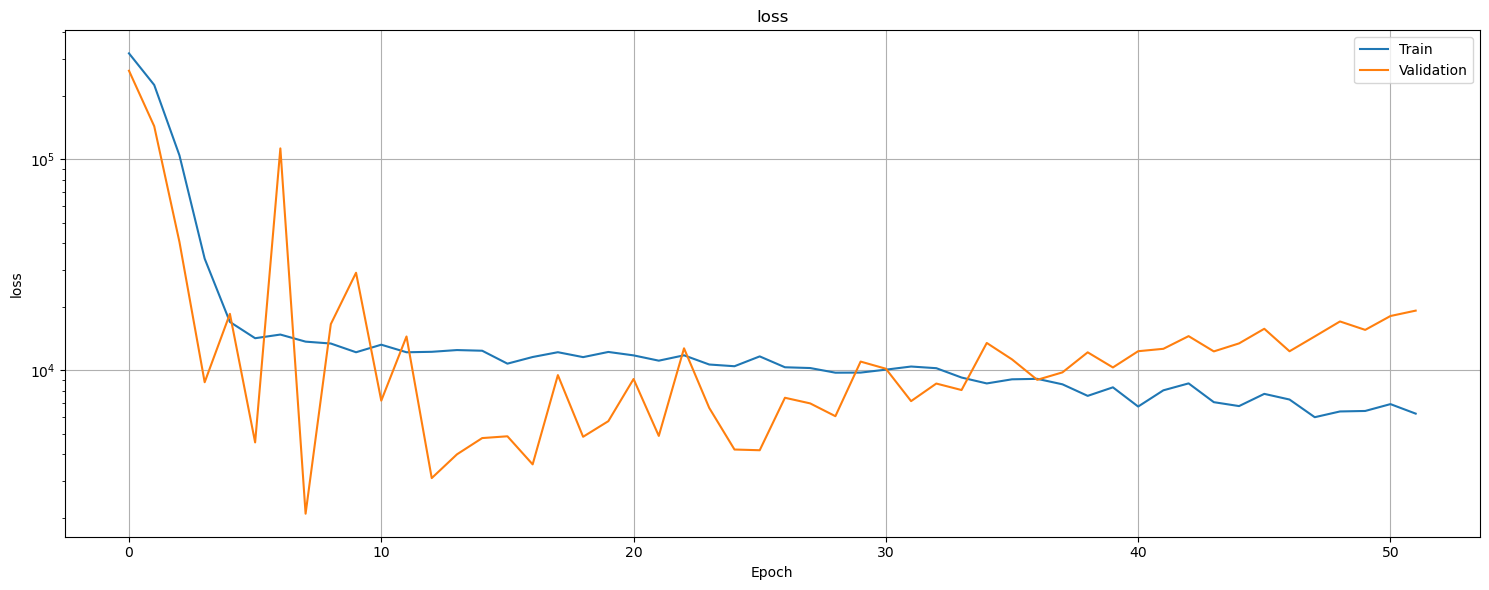

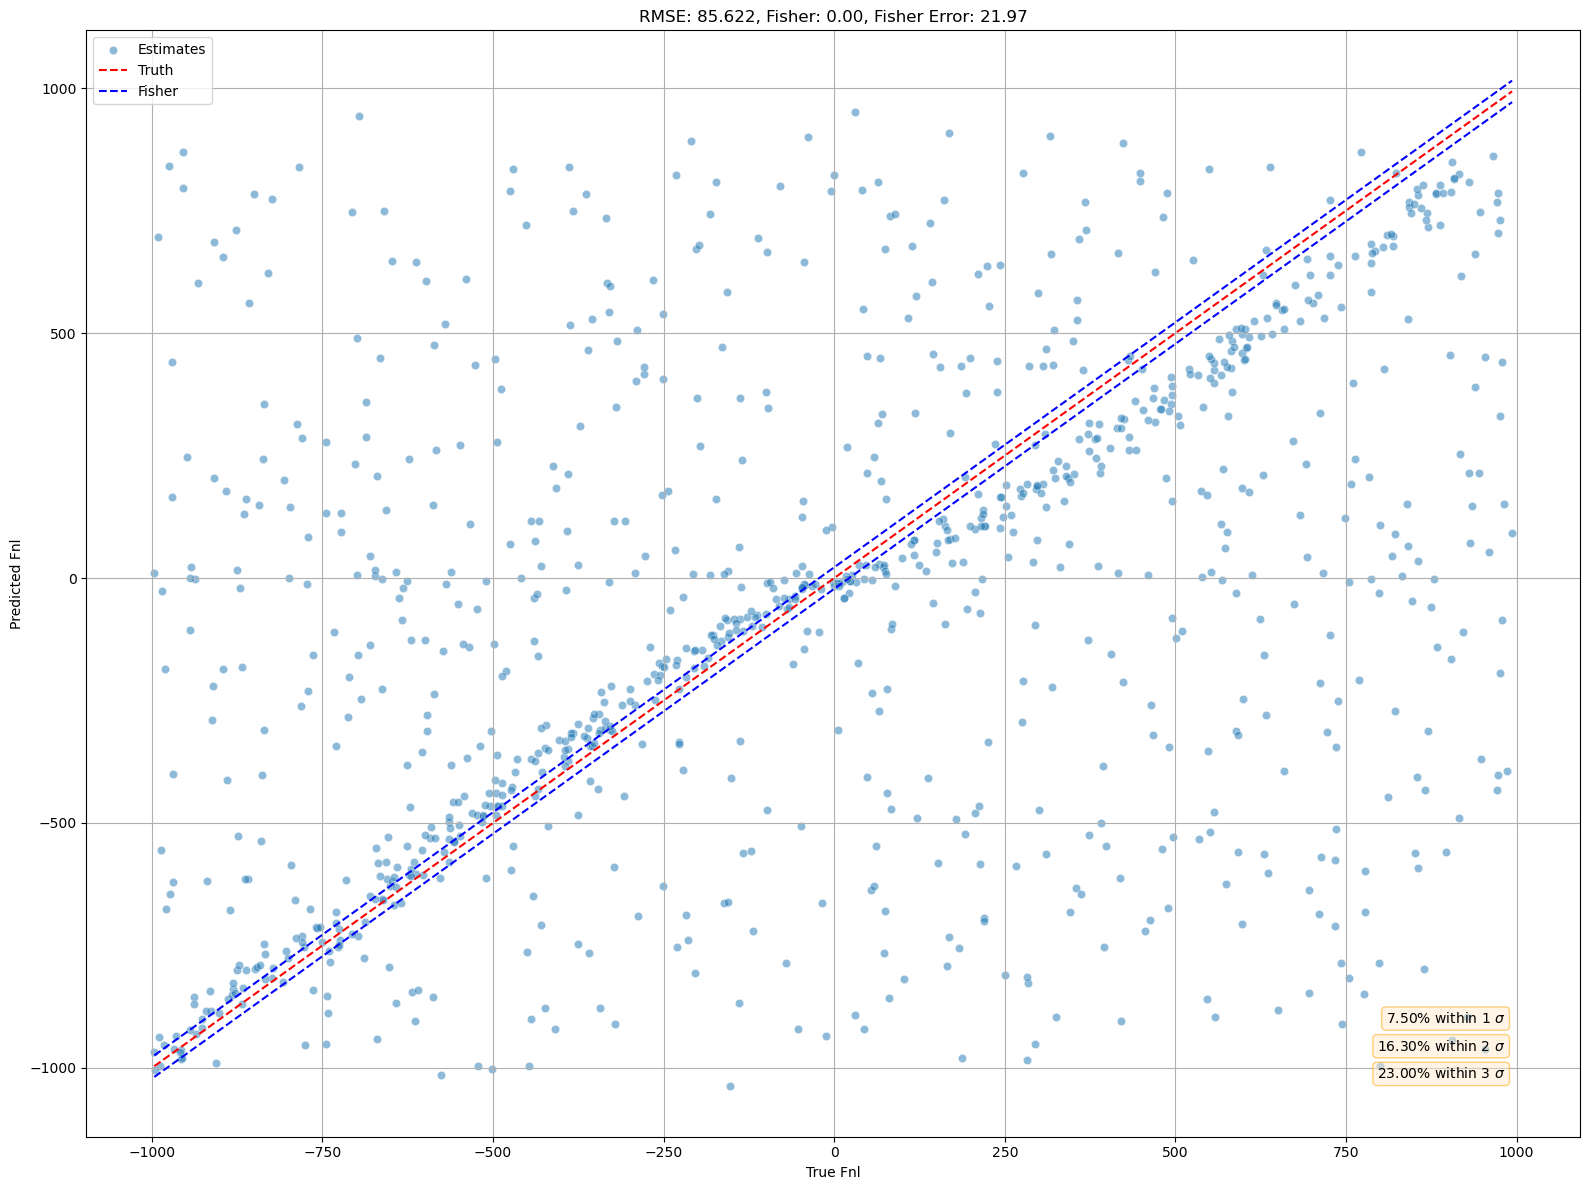

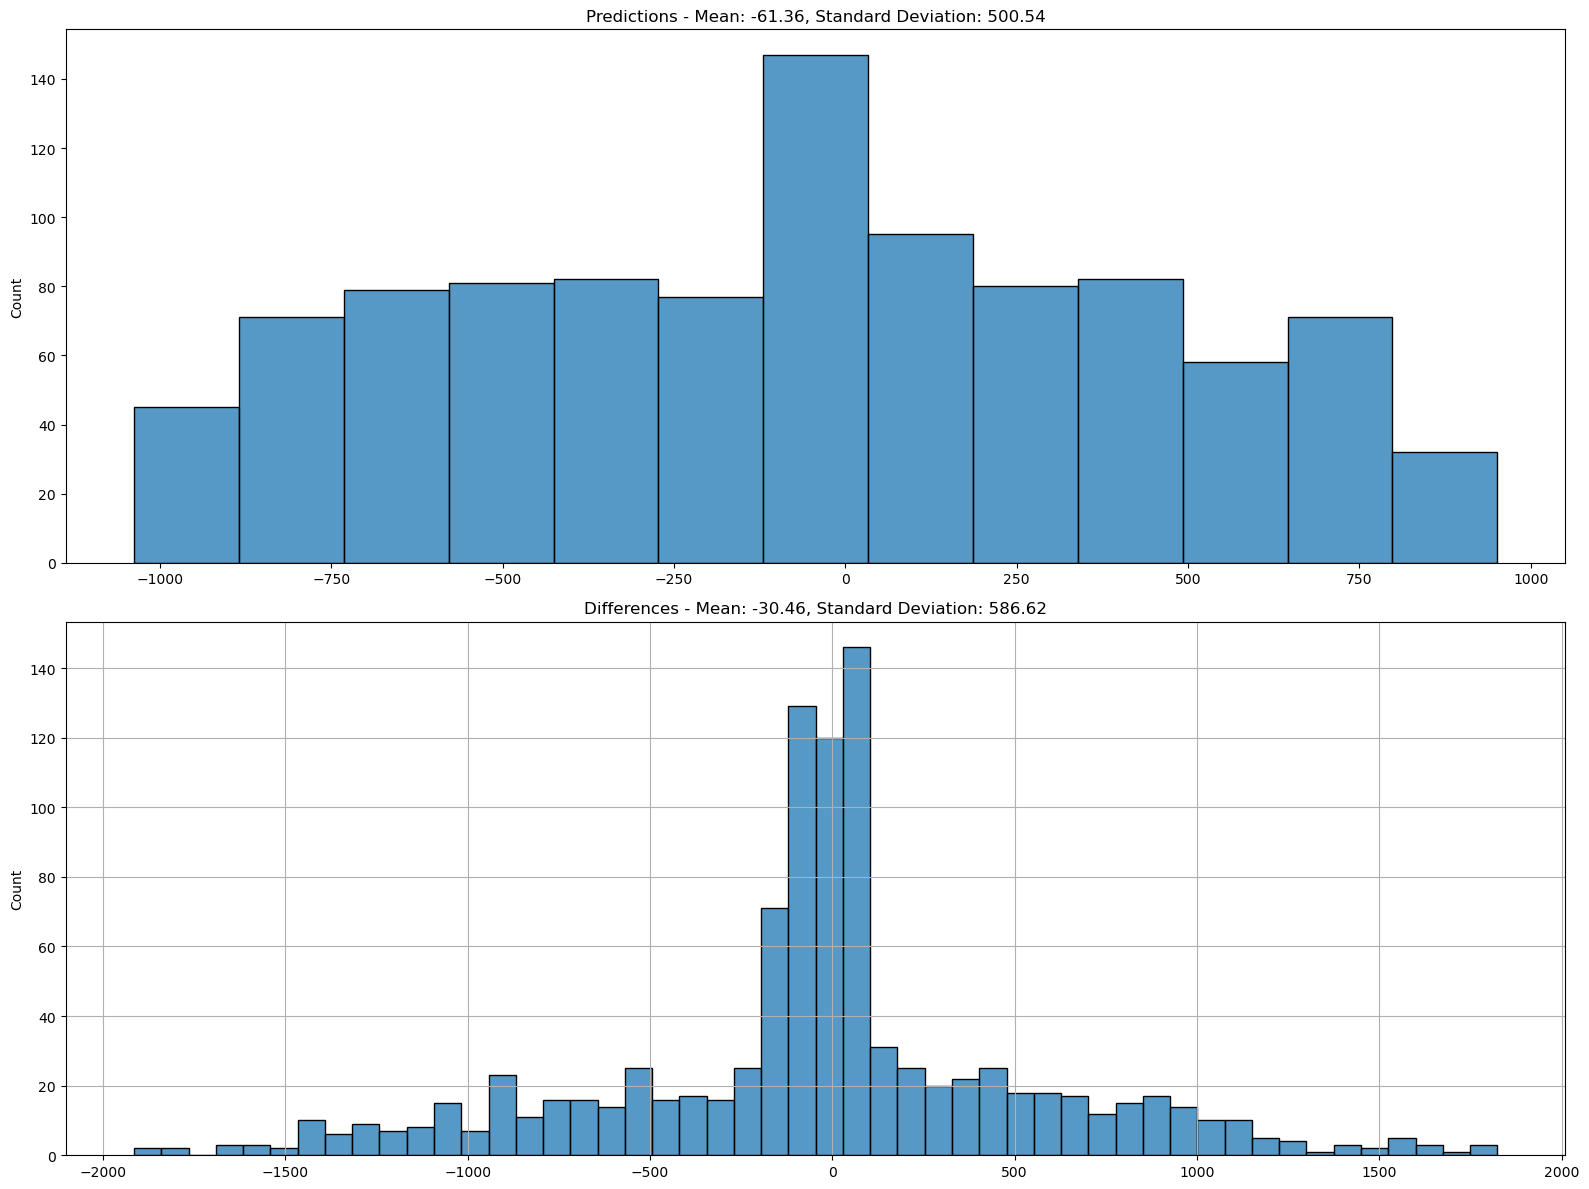

In [11]:
fisher = ds.get_fisher("local")
print_errors(y, preds, fisher)
plot_metrics(history, metrics=["loss"], show=True)
for shape in range(y.shape[1]):
    plot_predictions(
        y[:, shape],
        preds[:, shape],
        fisher=fisher,
        title=f"RMSE: {rmse:.3f}",
        show=True,
    )
    plot_histogram(y[:, shape], preds[:, shape], show=True)